# Import Libraries

In [23]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

sns.set_style("whitegrid")

# Load Dataset

In [24]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


# Dataset Information

In [25]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names")
print(df.columns)

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Shape of Dataset: (150, 5)

Column Names
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species'],
      dtype='object')

Data Types
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
dtype: object

Missing Values
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Duplicate Rows: 1


# Descriptive Statistics

In [26]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


# Visualisation

### Count Plot

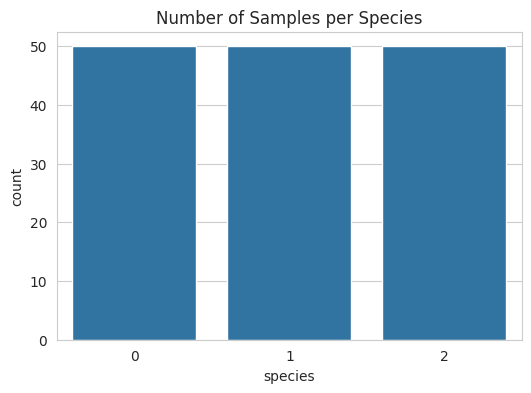

In [27]:
plt.figure(figsize=(6,4))

sns.countplot(x="species", data=df)

plt.title("Number of Samples per Species")
plt.show()

### Pairplot

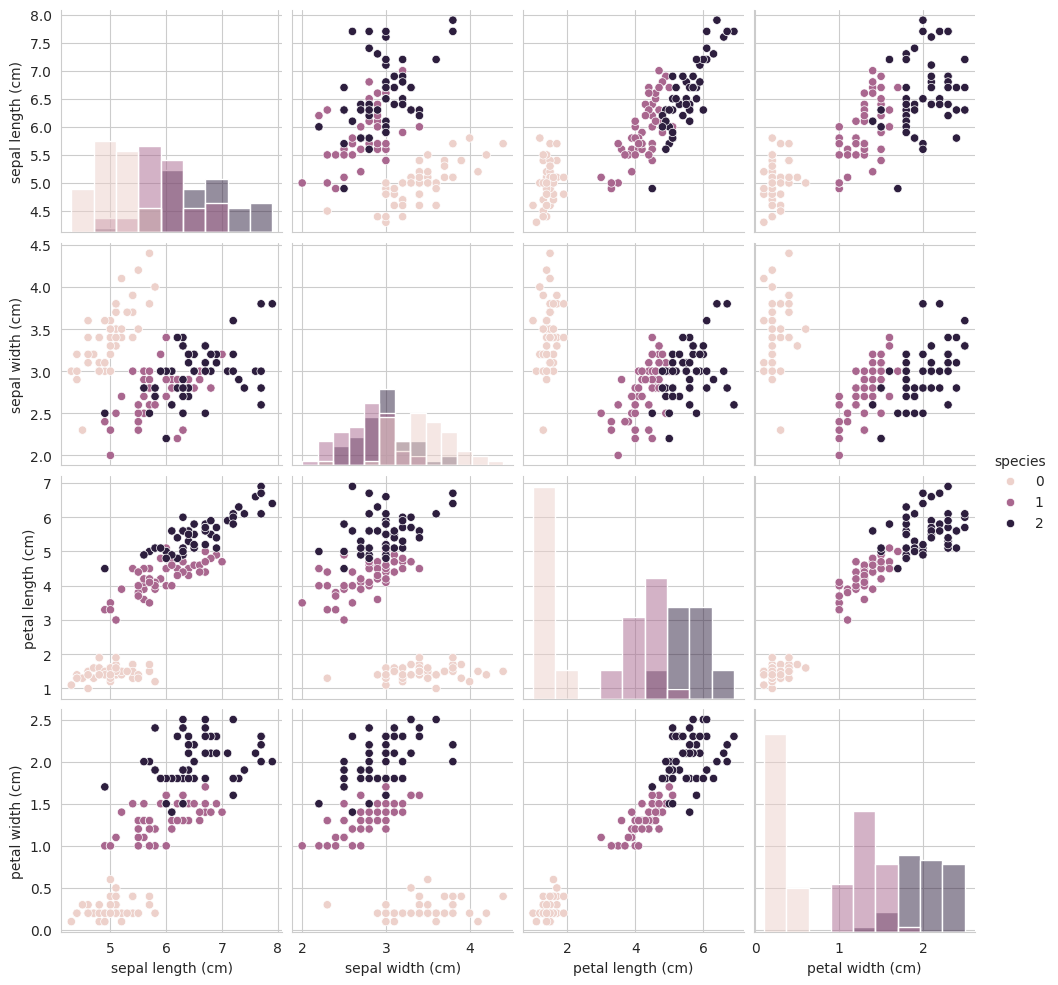

In [28]:
sns.pairplot(
    df,
    hue="species",
    diag_kind="hist"
)
plt.show()

### Boxplot

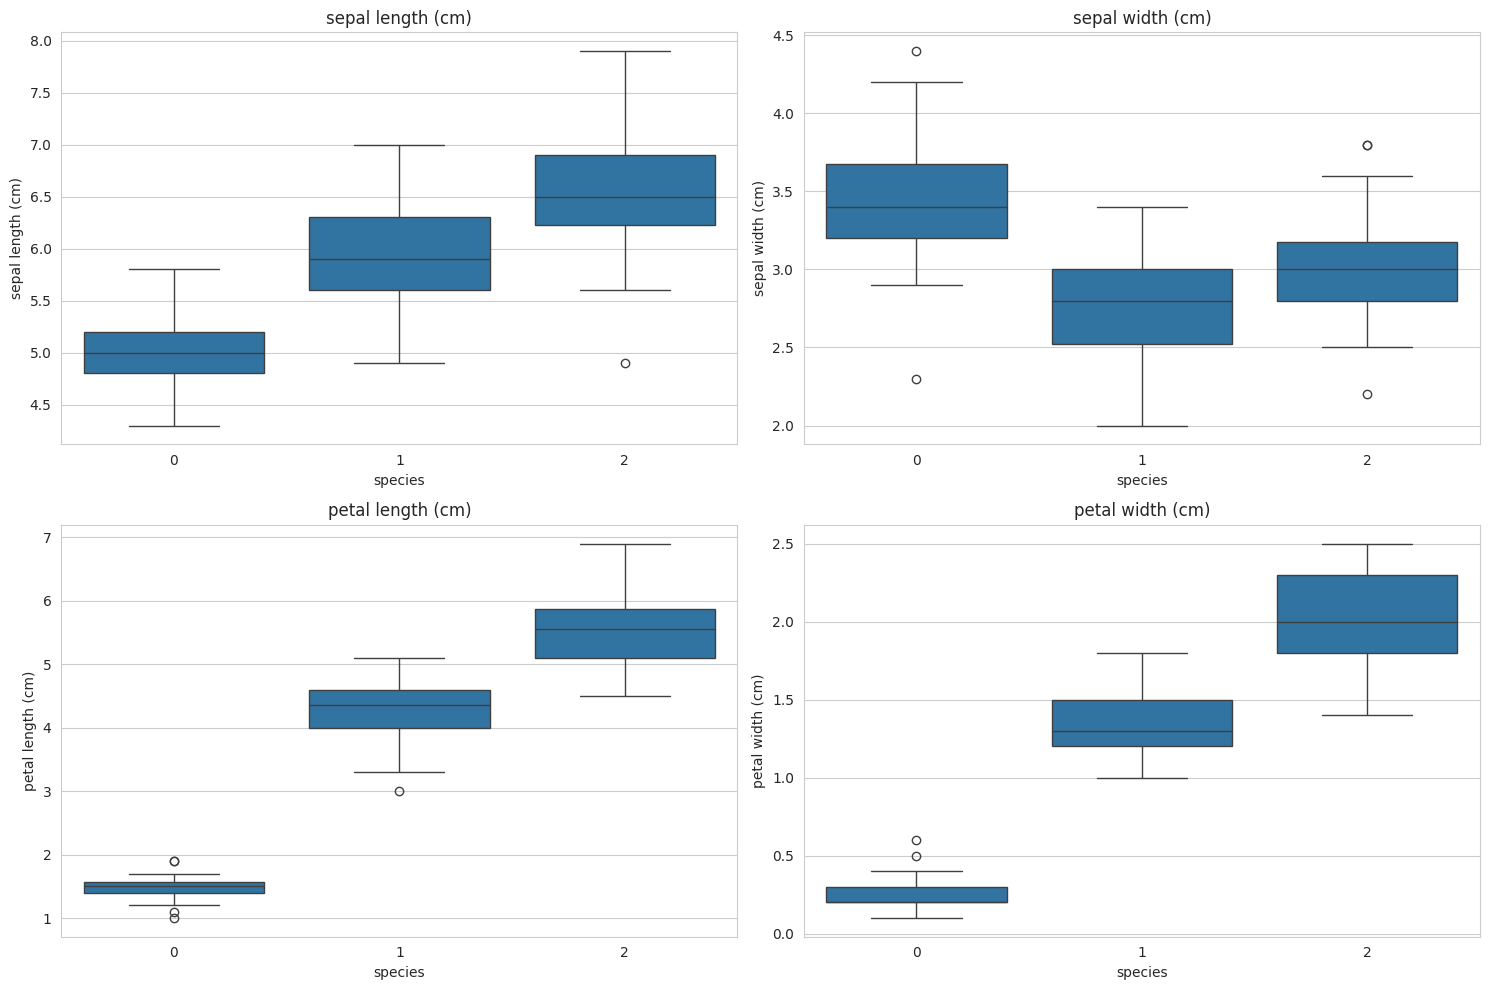

In [29]:
features = iris.feature_names
plt.figure(figsize=(15,10))

for i, feature in enumerate(features):
    plt.subplot(2,2,i+1)
    sns.boxplot(
        x="species",
        y=feature,
        data=df
    )
    plt.title(feature)
plt.tight_layout()
plt.show()

### Correlation Heatmap

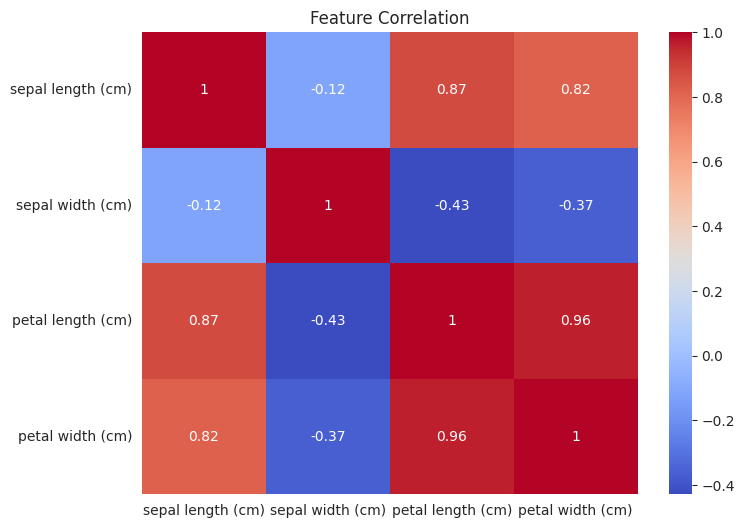

In [30]:
plt.figure(figsize=(8,6))

corr = df.drop("species", axis=1).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")
plt.show()

```
Feature Selection Discussion

1. Petal Length and Petal Width clearly separate the three species.
2. Sepal Length provides moderate discrimination.
3. Sepal Width contributes the least.

Hence, Petal Length and Petal Width are the most discriminative features.
```

# Prepare Data

In [31]:
X = df.drop("species", axis=1)

y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (120, 4)
Testing Samples: (30, 4)


### Logistic Regression

Accuracy: 0.9666666666666667

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



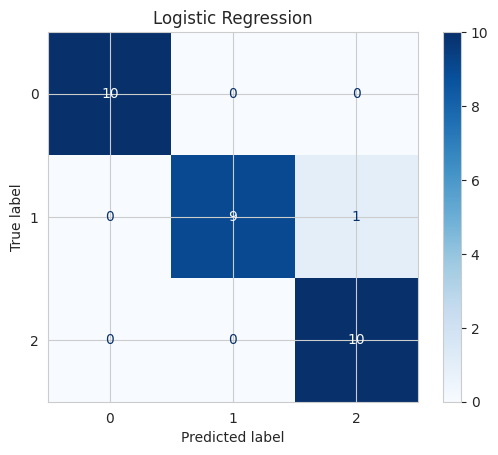

In [32]:
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, lr_pred))
print("\nClassification Report\n")
print(classification_report(y_test, lr_pred))

cm = confusion_matrix(y_test, lr_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=lr.classes_
)

disp.plot(cmap="Blues")
plt.title("Logistic Regression")
plt.show()

### K Nearest Neighbour

Accuracy: 1.0

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



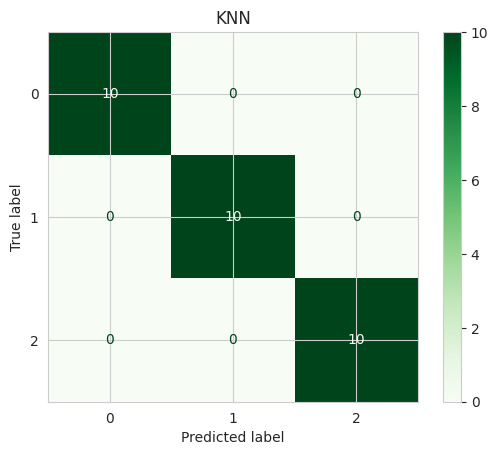

In [33]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, knn_pred))
print("\nClassification Report\n")
print(classification_report(y_test, knn_pred))

cm = confusion_matrix(y_test, knn_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=knn.classes_
)

disp.plot(cmap="Greens")
plt.title("KNN")
plt.show()

### Decision Tree

Accuracy: 0.9333333333333333

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



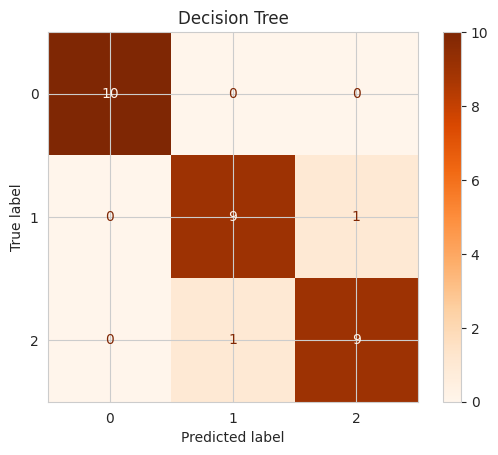

In [34]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, dt_pred))
print("\nClassification Report\n")
print(classification_report(y_test, dt_pred))

cm = confusion_matrix(y_test, dt_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=dt.classes_
)

disp.plot(cmap="Oranges")
plt.title("Decision Tree")
plt.show()

### Random Forest

Accuracy: 0.9

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.82      0.90      0.86        10
           2       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



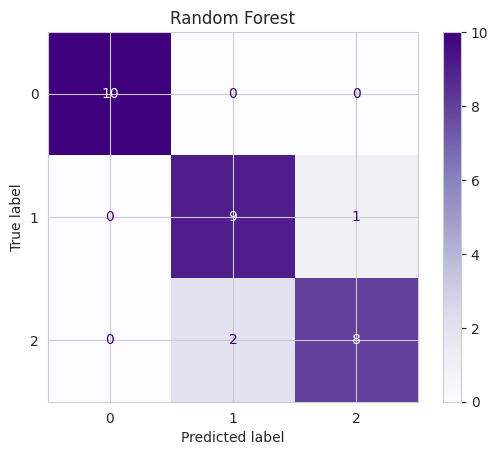

In [35]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report\n")
print(classification_report(y_test, rf_pred))

cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf.classes_
)

disp.plot(cmap="Purples")
plt.title("Random Forest")
plt.show()

### Compare the models

In [36]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy: 0.9666666666666667
KNN Accuracy: 1.0
Decision Tree Accuracy: 0.9333333333333333
Random Forest Accuracy: 0.9


## Best Performing Model

The best-performing model is **K N Neighbours** (or whichever model your notebook prints).

### Justification
- It achieved the highest accuracy on the test dataset.
- It correctly classified the maximum number of Iris flower samples.
- It produced strong precision, recall, and F1-score in the classification report.
- Therefore, it is selected as the best model for this Iris flower classification task.